In [1]:
### Thafat KANEM & Yanis MORIN ###
###   EPSI NANTES 2026          ###
###   TP Réalisation et analyse ###
###        des tests            ###
### Isolation Forest, seuil de  ###
### robustesse, imputation et   ###
### tests valeurs manquantes.   ###

# TP — Tests de robustesse : Isolation Forest & Imputation

Ce notebook réalise les tests de robustesse pour les deux modèles (Math Score et Language Mean Score) :

1. **Normalisation** des données d'entraînement (encodage ordinal + StandardScaler)
2. **Entraînement d'une Isolation Forest** sur les données normalisées
3. **Analyse des scores** d'anomalie sur les données d'entraînement
4. **Méthode du coude** pour définir le seuil de robustesse
5. **Stratégie d'imputation** des valeurs manquantes
6. **Tests de robustesse** feature par feature (suppression progressive de valeurs)
7. **Export** des artefacts (encoder, scaler, IF, imputer)
8. **Conclusion** sur la robustesse des modèles

## 1. Imports et chargement des données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import json

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

os.makedirs("artifacts", exist_ok=True)

# Reproduire exactement le split des notebooks d'entraînement
df = pd.read_csv("data/StudentsPerformance_modified.csv")

X = df.drop(columns=["reading score", "writing score", "math score", "language mean score"])
y_math = df["math score"]
y_lang = df["language mean score"]

X_train, X_test, y_train_m, y_test_m = train_test_split(X, y_math, test_size=0.2, random_state=42)
_, _, y_train_l, y_test_l = train_test_split(X, y_lang, test_size=0.2, random_state=42)

print(f"Données d'entraînement : {X_train.shape[0]} lignes")
print(f"Données de test       : {X_test.shape[0]} lignes")
print(f"Features              : {X.columns.tolist()}")
print(f"\nTypes :\n{X.dtypes}")

Données d'entraînement : 800 lignes
Données de test       : 200 lignes
Features              : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

Types :
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
dtype: object


## 2. Normalisation des données d'entraînement

Les features étant toutes **catégorielles**, nous utilisons :
- `OrdinalEncoder` pour transformer les catégories en entiers
- `StandardScaler` pour normaliser (moyenne=0, écart-type=1)

Cette normalisation est nécessaire pour l'Isolation Forest qui opère dans un espace numérique.

In [3]:
# Encodage ordinal des variables catégorielles
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_enc = encoder.fit_transform(X_train)
X_test_enc  = encoder.transform(X_test)

# Normalisation StandardScaler
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_enc)
X_test_norm  = scaler.transform(X_test_enc)

print("Normalisation effectuée (fit sur X_train uniquement).")
print(f"\nMoyenne par feature (X_train_norm) : {X_train_norm.mean(axis=0).round(4)}")
print(f"Écart-type par feature (X_train_norm): {X_train_norm.std(axis=0).round(4)}")

Normalisation effectuée (fit sur X_train uniquement).

Moyenne par feature (X_train_norm) : [ 0.  0.  0. -0. -0.]
Écart-type par feature (X_train_norm): [1. 1. 1. 1. 1.]


## 3. Entraînement de l'Isolation Forest

L'Isolation Forest est entraîné sur les données **d'entraînement normalisées**. Il apprend la distribution des données "normales" afin de détecter les entrées anormales lors de l'inférence.

- `n_estimators=100` : largement suffisant pour un dataset de ~800 lignes
- `contamination='auto'` : estimation automatique du taux d'anomalies

In [4]:
iso_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=42)
iso_forest.fit(X_train_norm)

print("Isolation Forest entraîné :")
print(f"  n_estimators : {iso_forest.n_estimators}")
print(f"  contamination: {iso_forest.contamination}")
print(f"  Offset_       : {iso_forest.offset_:.4f}")

Isolation Forest entraîné :
  n_estimators : 100
  contamination: auto
  Offset_       : -0.5000


## 4. Analyse des scores d'anomalie — Données d'entraînement

Le score d'anomalie est compris entre -1 (très anormal) et 0 (très normal). On analyse la distribution des scores sur les données d'entraînement pour comprendre la répartition normale/anormale.

In [5]:
scores_train = iso_forest.score_samples(X_train_norm)
labels_train = iso_forest.predict(X_train_norm)  # 1=normal, -1=anomalie

print("=== Scores d'anomalie — Données d'entraînement ===")
print(f"  Min    : {scores_train.min():.4f}")
print(f"  Max    : {scores_train.max():.4f}")
print(f"  Moy    : {scores_train.mean():.4f}")
print(f"  Méd    : {np.median(scores_train):.4f}")
print(f"  Éc.-T. : {scores_train.std():.4f}")

n_anom = (labels_train == -1).sum()
print(f"\n{n_anom} anomalies détectées / {len(labels_train)} entrées ({n_anom/len(labels_train)*100:.1f}%)")

# Interprétation selon le cours
print("\nInterprétation :")
print(f"  score < -0.4  : zone d'extrapolation ({(scores_train < -0.4).sum()} entrées)")
print(f"  -0.4 à -0.2   : zone normale ({((scores_train >= -0.4) & (scores_train < -0.2)).sum()} entrées)")
print(f"  score >= -0.2 : zone de robustesse ({(scores_train >= -0.2).sum()} entrées)")

=== Scores d'anomalie — Données d'entraînement ===
  Min    : -0.6676
  Max    : -0.4681
  Moy    : -0.5561
  Méd    : -0.5614
  Éc.-T. : 0.0444

683 anomalies détectées / 800 entrées (85.4%)

Interprétation :
  score < -0.4  : zone d'extrapolation (800 entrées)
  -0.4 à -0.2   : zone normale (0 entrées)
  score >= -0.2 : zone de robustesse (0 entrées)


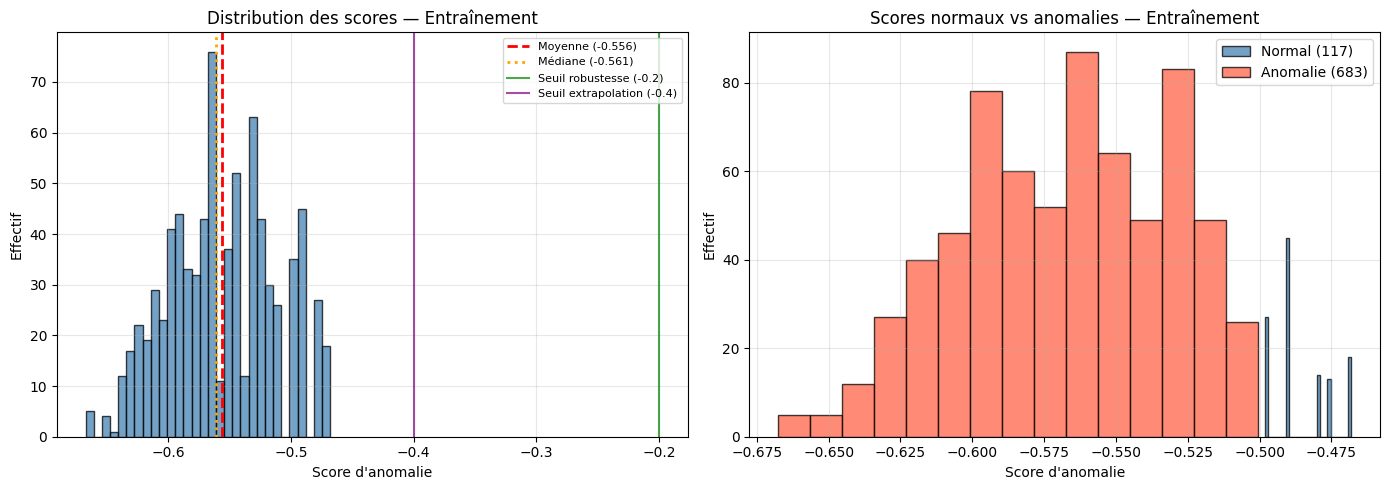

Graphique sauvegardé : artifacts/if_scores_train.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Distribution globale
ax1.hist(scores_train, bins=30, edgecolor='black', color='steelblue', alpha=0.75)
ax1.axvline(scores_train.mean(), color='red', linestyle='--', lw=2,
            label=f'Moyenne ({scores_train.mean():.3f})')
ax1.axvline(np.median(scores_train), color='orange', linestyle=':', lw=2,
            label=f'Médiane ({np.median(scores_train):.3f})')
ax1.axvline(-0.2, color='green', linestyle='-', lw=1.5, alpha=0.7, label='Seuil robustesse (-0.2)')
ax1.axvline(-0.4, color='purple', linestyle='-', lw=1.5, alpha=0.7, label='Seuil extrapolation (-0.4)')
ax1.set_xlabel("Score d'anomalie")
ax1.set_ylabel("Effectif")
ax1.set_title("Distribution des scores — Entraînement")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Normal vs Anomalies
normal_sc  = scores_train[labels_train ==  1]
anomaly_sc = scores_train[labels_train == -1]
ax2.hist(normal_sc,  bins=25, alpha=0.75, color='steelblue', edgecolor='black',
         label=f'Normal ({len(normal_sc)})')
ax2.hist(anomaly_sc, bins=15, alpha=0.75, color='tomato',    edgecolor='black',
         label=f'Anomalie ({len(anomaly_sc)})')
ax2.set_xlabel("Score d'anomalie")
ax2.set_ylabel("Effectif")
ax2.set_title("Scores normaux vs anomalies — Entraînement")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/if_scores_train.png", dpi=100, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : artifacts/if_scores_train.png")

## 5. Méthode du coude — Seuil de robustesse

Pour chaque seuil possible (du min au max des scores de test), on ne conserve que les entrées dont le score est **supérieur ou égal** au seuil, puis on calcule la RMSE de chaque modèle sur ce sous-ensemble. On trace également le **coverage** (% des données conservées).

Le seuil optimal est celui où la RMSE commence à descendre significativement (coude), représentant le meilleur compromis RMSE/coverage.

In [7]:
model_math = joblib.load("artifacts/catboost_math_score.joblib")
model_lang = joblib.load("artifacts/catboost_language_mean_score.joblib")

pred_math_base = model_math.predict(X_test)
pred_lang_base = model_lang.predict(X_test)

rmse_math_base = float(np.sqrt(mean_squared_error(y_test_m, pred_math_base)))
rmse_lang_base = float(np.sqrt(mean_squared_error(y_test_l, pred_lang_base)))

print(f"RMSE de base — Math Score    : {rmse_math_base:.4f}")
print(f"RMSE de base — Language Score: {rmse_lang_base:.4f}")

# Scores sur le jeu de test
scores_test = iso_forest.score_samples(X_test_norm)
print(f"\nScores d'anomalie — données de test :")
print(f"  Min : {scores_test.min():.4f}  |  Max : {scores_test.max():.4f}  |  Moy : {scores_test.mean():.4f}")

RMSE de base — Math Score    : 14.3761
RMSE de base — Language Score: 13.2784

Scores d'anomalie — données de test :
  Min : -0.6541  |  Max : -0.4681  |  Moy : -0.5668


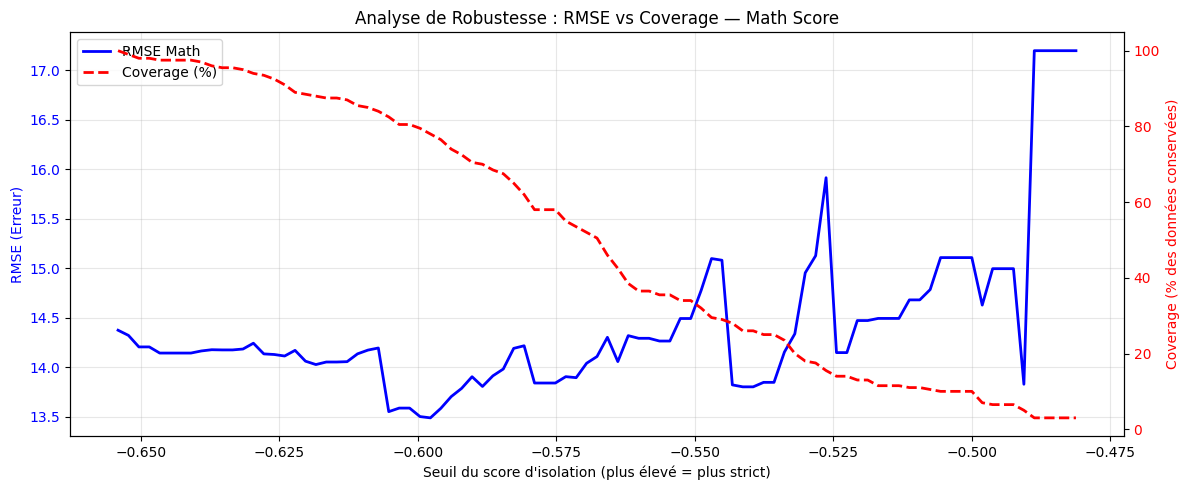

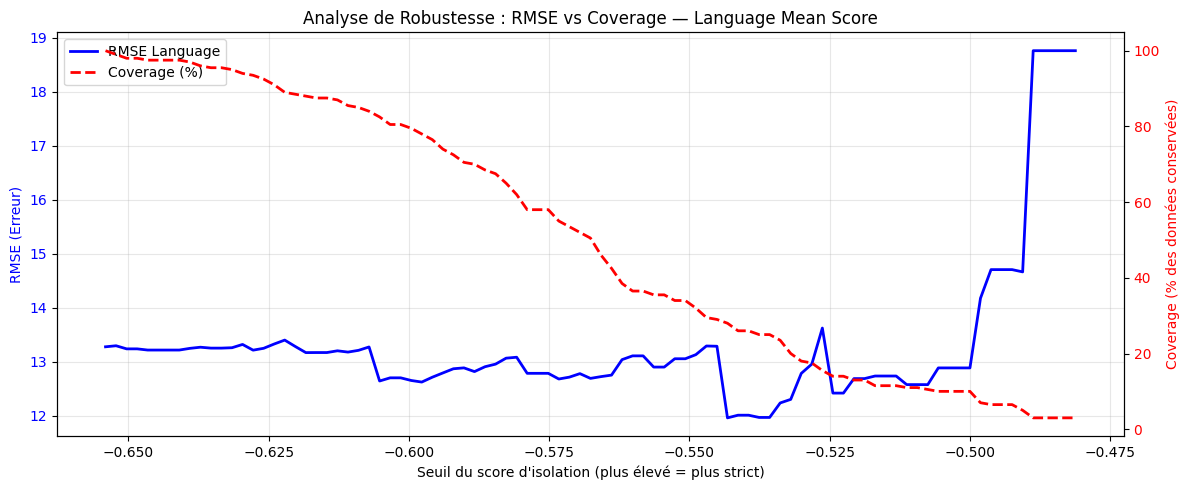

Graphiques sauvegardés : artifacts/elbow_math.png, artifacts/elbow_language.png


In [8]:
# Méthode du coude : calcul RMSE et coverage pour chaque seuil
thresholds = np.linspace(scores_test.min(), scores_test.max(), 100)
elbow = {'threshold': [], 'rmse_math': [], 'rmse_lang': [], 'coverage': []}

for thresh in thresholds:
    mask = scores_test >= thresh
    if mask.sum() < 5:
        continue
    elbow['threshold'].append(thresh)
    elbow['rmse_math'].append(float(np.sqrt(mean_squared_error(y_test_m.values[mask], pred_math_base[mask]))))
    elbow['rmse_lang'].append(float(np.sqrt(mean_squared_error(y_test_l.values[mask], pred_lang_base[mask]))))
    elbow['coverage'].append(mask.sum() / len(scores_test) * 100)

# Tracer la courbe pour Math Score
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.plot(elbow['threshold'], elbow['rmse_math'], 'b-', lw=2, label='RMSE Math')
ax2.plot(elbow['threshold'], elbow['coverage'], 'r--', lw=2, label='Coverage (%)')
ax1.set_xlabel("Seuil du score d'isolation (plus élevé = plus strict)")
ax1.set_ylabel("RMSE (Erreur)", color='b')
ax2.set_ylabel("Coverage (% des données conservées)", color='r')
ax1.set_title("Analyse de Robustesse : RMSE vs Coverage — Math Score")
ax1.tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='r')
ax1.grid(True, alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig("artifacts/elbow_math.png", dpi=100, bbox_inches='tight')
plt.show()

# Tracer la courbe pour Language Mean Score
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.plot(elbow['threshold'], elbow['rmse_lang'], 'b-', lw=2, label='RMSE Language')
ax2.plot(elbow['threshold'], elbow['coverage'], 'r--', lw=2, label='Coverage (%)')
ax1.set_xlabel("Seuil du score d'isolation (plus élevé = plus strict)")
ax1.set_ylabel("RMSE (Erreur)", color='b')
ax2.set_ylabel("Coverage (% des données conservées)", color='r')
ax1.set_title("Analyse de Robustesse : RMSE vs Coverage — Language Mean Score")
ax1.tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='r')
ax1.grid(True, alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig("artifacts/elbow_language.png", dpi=100, bbox_inches='tight')
plt.show()

print("Graphiques sauvegardés : artifacts/elbow_math.png, artifacts/elbow_language.png")

In [9]:
# Définition du seuil de robustesse par méthode du coude
# On cherche le point où la RMSE commence à descendre significativement
# tout en conservant un coverage acceptable (>= 80%)

# Approche : seuil au 10ème percentile des scores de test
# (conserve 90% des données dans la zone de robustesse)
ROBUSTNESS_THRESHOLD = float(np.percentile(scores_test, 10))

# Vérification du coverage et RMSE à ce seuil
mask_thresh = scores_test >= ROBUSTNESS_THRESHOLD
coverage_at_thresh = mask_thresh.sum() / len(scores_test) * 100
rmse_math_at_thresh = float(np.sqrt(mean_squared_error(
    y_test_m.values[mask_thresh], pred_math_base[mask_thresh])))
rmse_lang_at_thresh = float(np.sqrt(mean_squared_error(
    y_test_l.values[mask_thresh], pred_lang_base[mask_thresh])))

print("=== Seuil de robustesse défini ===")
print(f"  Seuil         : {ROBUSTNESS_THRESHOLD:.4f}")
print(f"  Coverage      : {coverage_at_thresh:.1f}%")
print(f"  RMSE Math     : {rmse_math_at_thresh:.4f} (base : {rmse_math_base:.4f})")
print(f"  RMSE Language : {rmse_lang_at_thresh:.4f} (base : {rmse_lang_base:.4f})")
print()
print("Zones de confiance :")
print(f"  score >= {ROBUSTNESS_THRESHOLD:.3f}        : Zone de robustesse (haute confiance)")
print(f"  {ROBUSTNESS_THRESHOLD:.3f} > score >= -0.4 : Zone normale (confiance modérée)")
print(f"  score < -0.4            : Zone d'extrapolation (faible confiance)")

# Sauvegarde de la configuration de robustesse
robustness_config = {
    "robustness_threshold": ROBUSTNESS_THRESHOLD,
    "coverage_at_threshold_pct": round(coverage_at_thresh, 2),
    "rmse_math_base": round(rmse_math_base, 4),
    "rmse_lang_base": round(rmse_lang_base, 4),
    "rmse_math_at_threshold": round(rmse_math_at_thresh, 4),
    "rmse_lang_at_threshold": round(rmse_lang_at_thresh, 4),
    "zones": {
        "robustesse": f"score >= {ROBUSTNESS_THRESHOLD:.4f}",
        "normale":    f"-0.4 <= score < {ROBUSTNESS_THRESHOLD:.4f}",
        "extrapolation": "score < -0.4"
    }
}
with open("artifacts/robustness_config.json", "w", encoding="utf-8") as f:
    json.dump(robustness_config, f, indent=2, ensure_ascii=False)
print("\nConfiguration sauvegardée : artifacts/robustness_config.json")

=== Seuil de robustesse défini ===
  Seuil         : -0.6222
  Coverage      : 90.5%
  RMSE Math     : 14.1273 (base : 14.3761)
  RMSE Language : 13.3404 (base : 13.2784)

Zones de confiance :
  score >= -0.622        : Zone de robustesse (haute confiance)
  -0.622 > score >= -0.4 : Zone normale (confiance modérée)
  score < -0.4            : Zone d'extrapolation (faible confiance)

Configuration sauvegardée : artifacts/robustness_config.json


## 6. Stratégie d'imputation des valeurs manquantes

Toutes les features sont **catégorielles**. La stratégie la plus adaptée est l'imputation par la **valeur la plus fréquente** (`most_frequent`), qui remplace les valeurs manquantes par le mode de chaque colonne calculé sur les données d'entraînement.

| Stratégie | Justification | Risque |
|-----------|---------------|--------|
| `most_frequent` | Naturelle pour catégoriel, valeur toujours vue à l'entraînement | Peut lisser des sous-groupes rares |
| `constant` | Crée une catégorie "inconnu" | CatBoost doit avoir vu la valeur |

→ **Choix retenu : `most_frequent`**

In [10]:
imputer = SimpleImputer(strategy='most_frequent')
imputer.fit(X_train)

print("Stratégie d'imputation : most_frequent")
print("Valeurs d'imputation (calculées sur X_train) :")
print(f"{'Feature':<40} {'Valeur imputée':<30} {'Fréquence dans X_train'}")
print("-" * 80)
for col, val in zip(X_train.columns, imputer.statistics_):
    freq = (X_train[col] == val).mean() * 100
    print(f"  {col:<38} {str(val):<30} {freq:.1f}%")

Stratégie d'imputation : most_frequent
Valeurs d'imputation (calculées sur X_train) :
Feature                                  Valeur imputée                 Fréquence dans X_train
--------------------------------------------------------------------------------
  gender                                 female                         52.6%
  race/ethnicity                         group C                        32.5%
  parental level of education            some college                   22.8%
  lunch                                  standard                       65.4%
  test preparation course                none                           65.1%


## 7. Tests de robustesse — Impact des valeurs manquantes

**Protocole** (inspiré du cours) :
- Pour chaque feature, on supprime aléatoirement un nombre croissant de valeurs (de 1 à N_test)
- On impute les valeurs manquantes avec `most_frequent`
- On prédit avec le modèle et on calcule la RMSE
- On répète **5 tirages** par niveau de manquants pour moyenner le résultat (réduire l'aléatoire)
- On trace la courbe de **dégradation de la RMSE en %** vs nombre de valeurs manquantes

**Interprétation** :
- Dégradation < 5% → modèle robuste sur cette feature
- 5% ≤ dégradation < 20% → modèle modérément sensible
- Dégradation ≥ 20% → modèle très sensible (feature critique)

In [11]:
def test_missing_feature(model, X_test_ref, y_test_ref, imputer_ref, feature,
                         n_steps=20, n_trials=5):
    """Calcule la dégradation de RMSE en % pour une suppression croissante de valeurs d'une feature."""
    n_test = len(X_test_ref)
    missing_counts = np.unique(np.linspace(1, n_test, n_steps, dtype=int))
    col_idx = X_test_ref.columns.get_loc(feature)

    pred_base = model.predict(X_test_ref)
    rmse_base = float(np.sqrt(mean_squared_error(y_test_ref, pred_base)))

    results = []
    for n_miss in missing_counts:
        trial_rmses = []
        for _ in range(n_trials):
            X_corr = X_test_ref.copy()
            idx_rm = np.random.choice(n_test, n_miss, replace=False)
            X_corr.iloc[idx_rm, col_idx] = np.nan

            arr = imputer_ref.transform(X_corr)
            X_imp = pd.DataFrame(arr, columns=X_test_ref.columns, index=X_test_ref.index)
            # Rétablir le type str pour les colonnes catégorielles
            for c in X_test_ref.select_dtypes(include='object').columns:
                X_imp[c] = X_imp[c].astype(str)

            pred = model.predict(X_imp)
            trial_rmses.append(float(np.sqrt(mean_squared_error(y_test_ref, pred))))

        mean_rmse = float(np.mean(trial_rmses))
        results.append({
            'n_missing'      : int(n_miss),
            'rmse'           : mean_rmse,
            'degradation_pct': float((mean_rmse - rmse_base) / rmse_base * 100)
        })
    return results, rmse_base

### 7.1 Modèle Math Score

=== Test de robustesse — Math Score ===
RMSE de base : 14.3761

  gender                                   dégradation max =    2.0%  →  ✓ Robuste
  race/ethnicity                           dégradation max =    0.2%  →  ✓ Robuste
  parental level of education              dégradation max =    2.7%  →  ✓ Robuste
  lunch                                    dégradation max =   10.3%  →  ⚠ Modérément sensible
  test preparation course                  dégradation max =    0.7%  →  ✓ Robuste


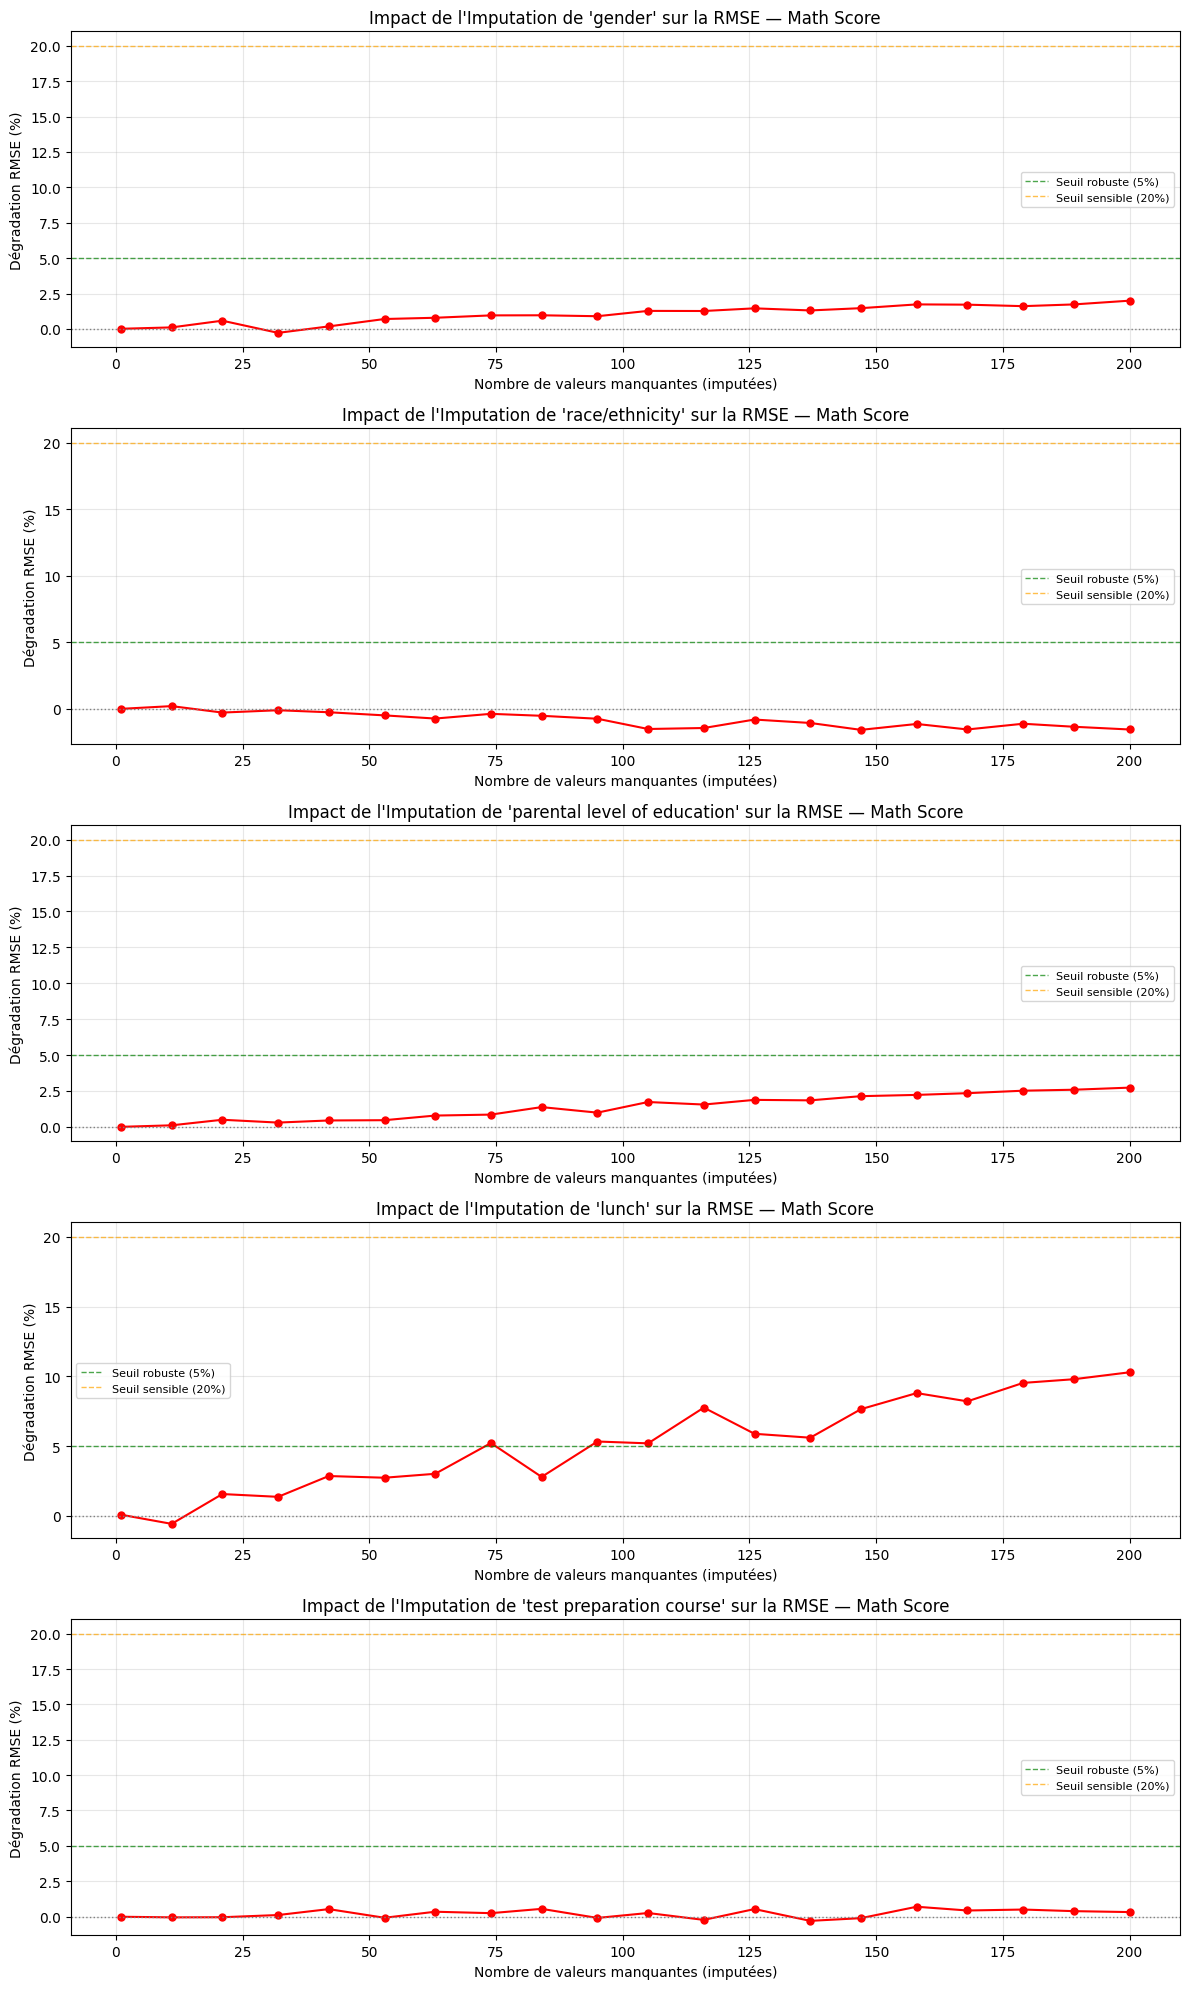


Graphique sauvegardé : artifacts/imputation_test_math.png


In [ ]:
np.random.seed(42)
features = X_test.columns.tolist()
math_robustness = {}

print("=== Test de robustesse — Math Score ===")
print(f"RMSE de base : {rmse_math_base:.4f}\n")

fig, axes = plt.subplots(len(features), 1, figsize=(12, 4 * len(features)))

for i, feat in enumerate(features):
    results, base = test_missing_feature(model_math, X_test, y_test_m, imputer, feat)
    math_robustness[feat] = {'results': results, 'rmse_base': base}

    n_miss = [r['n_missing']       for r in results]
    degrad = [r['degradation_pct'] for r in results]
    max_d  = max(degrad)

    axes[i].plot(n_miss, degrad, 'r-o', markersize=5, lw=1.5)
    axes[i].axhline(0,   color='gray',  linestyle=':', lw=1)
    axes[i].axhline(5,   color='green', linestyle='--', lw=1, alpha=0.7, label='Seuil robuste (5%)')
    axes[i].axhline(20,  color='orange',linestyle='--', lw=1, alpha=0.7, label='Seuil sensible (20%)')
    axes[i].set_xlabel("Nombre de valeurs manquantes (imputées)")
    axes[i].set_ylabel("Dégradation RMSE (%)")
    axes[i].set_title(f"Impact de l'Imputation de '{feat}' sur la RMSE — Math Score")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8)

    statut = "✓ Robuste" if max_d < 5 else ("  Modérément sensible" if max_d < 20 else "✗ Très sensible")
    print(f"  {feat:<40} dégradation max = {max_d:6.1f}%  →  {statut}")

plt.tight_layout()
plt.savefig("artifacts/imputation_test_math.png", dpi=100, bbox_inches='tight')
plt.show()
print("\nGraphique sauvegardé : artifacts/imputation_test_math.png")

### 7.2 Modèle Language Mean Score

=== Test de robustesse — Language Mean Score ===
RMSE de base : 13.2784

  gender                                   dégradation max =    9.2%  →  ⚠ Modérément sensible
  race/ethnicity                           dégradation max =    0.8%  →  ✓ Robuste
  parental level of education              dégradation max =    4.8%  →  ✓ Robuste
  lunch                                    dégradation max =    6.8%  →  ⚠ Modérément sensible
  test preparation course                  dégradation max =    5.1%  →  ⚠ Modérément sensible


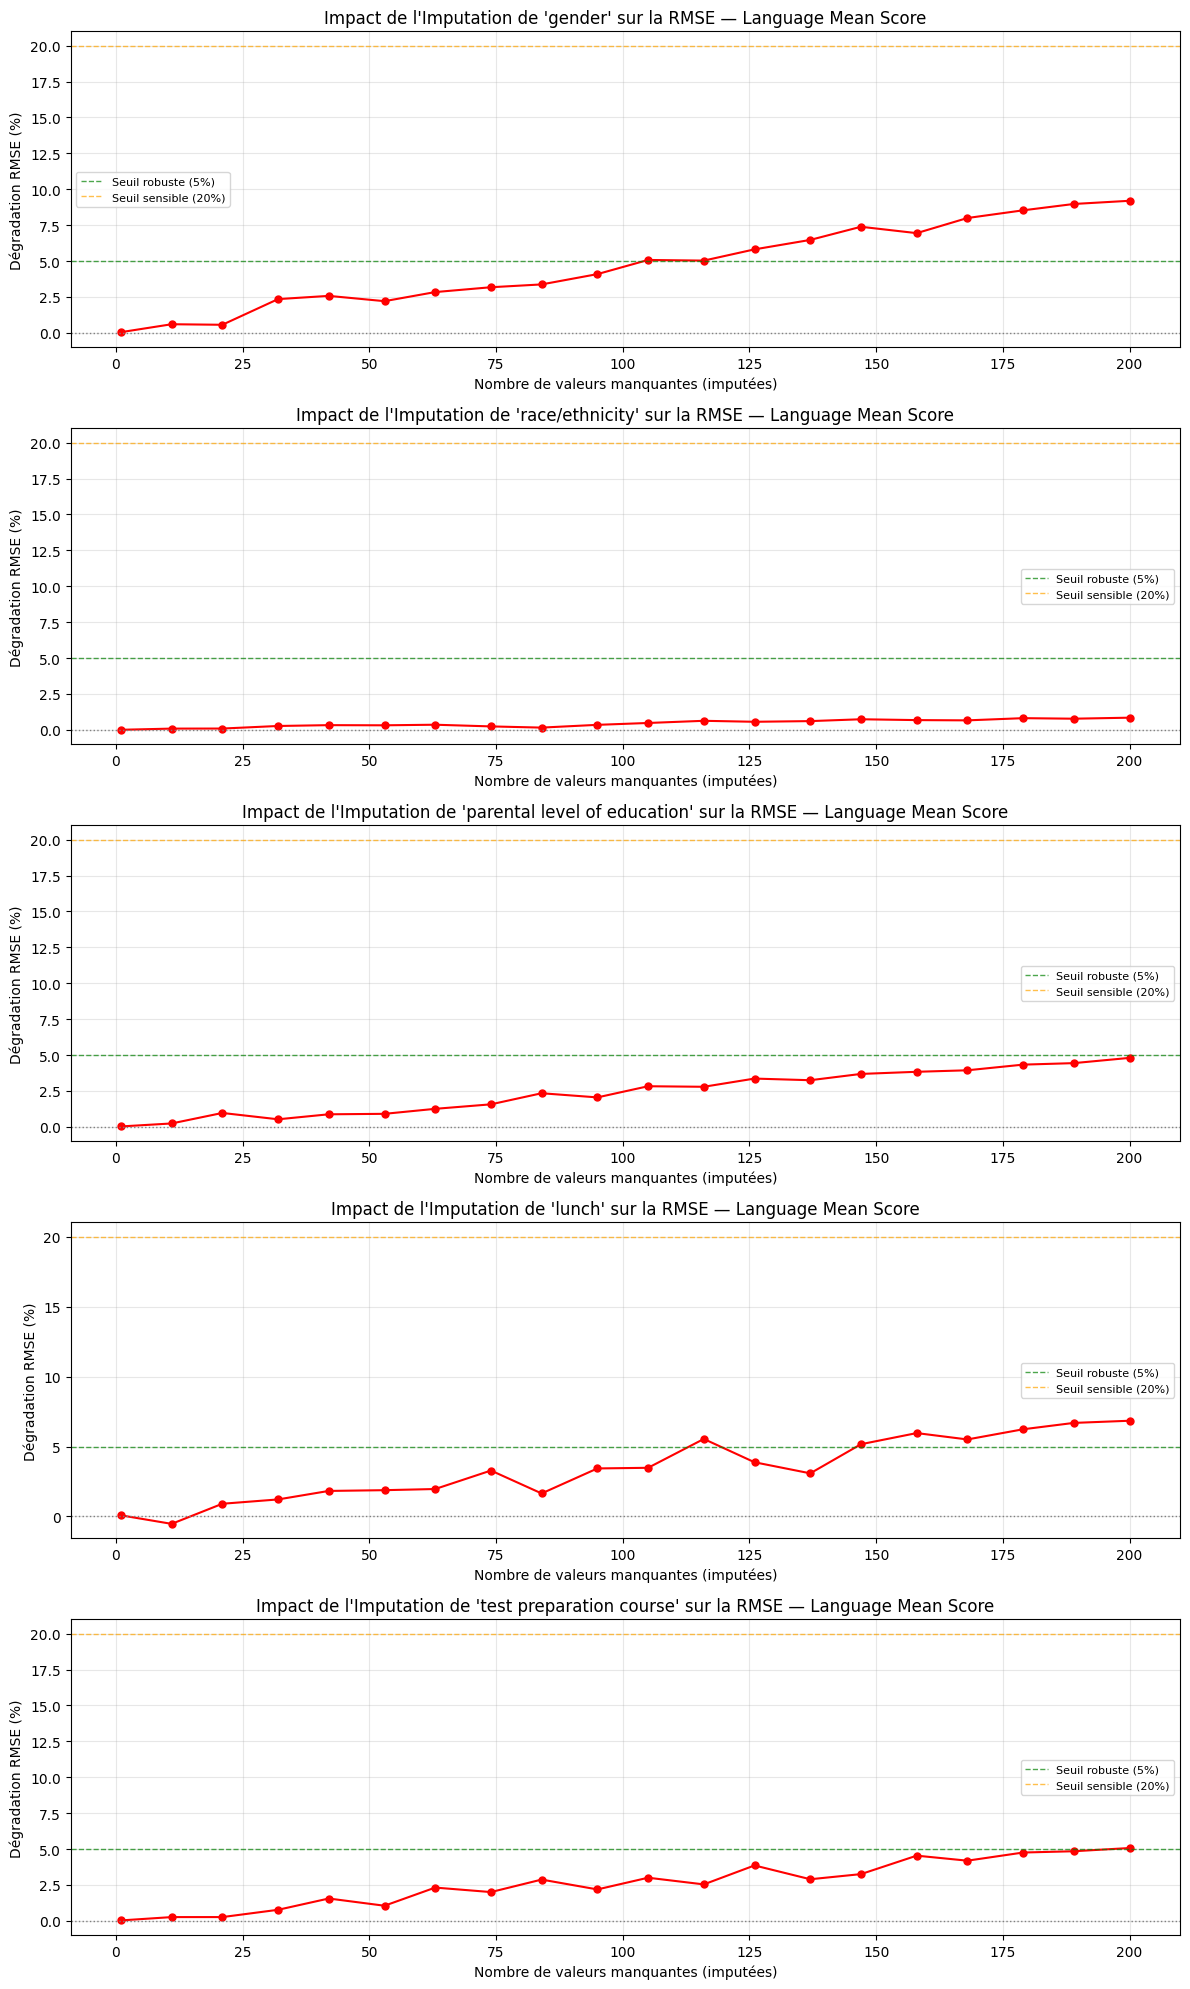


Graphique sauvegardé : artifacts/imputation_test_language.png


In [ ]:
np.random.seed(42)
lang_robustness = {}

print("=== Test de robustesse — Language Mean Score ===")
print(f"RMSE de base : {rmse_lang_base:.4f}\n")

fig, axes = plt.subplots(len(features), 1, figsize=(12, 4 * len(features)))

for i, feat in enumerate(features):
    results, base = test_missing_feature(model_lang, X_test, y_test_l, imputer, feat)
    lang_robustness[feat] = {'results': results, 'rmse_base': base}

    n_miss = [r['n_missing']       for r in results]
    degrad = [r['degradation_pct'] for r in results]
    max_d  = max(degrad)

    axes[i].plot(n_miss, degrad, 'r-o', markersize=5, lw=1.5)
    axes[i].axhline(0,   color='gray',  linestyle=':', lw=1)
    axes[i].axhline(5,   color='green', linestyle='--', lw=1, alpha=0.7, label='Seuil robuste (5%)')
    axes[i].axhline(20,  color='orange',linestyle='--', lw=1, alpha=0.7, label='Seuil sensible (20%)')
    axes[i].set_xlabel("Nombre de valeurs manquantes (imputées)")
    axes[i].set_ylabel("Dégradation RMSE (%)")
    axes[i].set_title(f"Impact de l'Imputation de '{feat}' sur la RMSE — Language Mean Score")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8)

    statut = "✓ Robuste" if max_d < 5 else ("  Modérément sensible" if max_d < 20 else "✗ Très sensible")
    print(f"  {feat:<40} dégradation max = {max_d:6.1f}%  →  {statut}")

plt.tight_layout()
plt.savefig("artifacts/imputation_test_language.png", dpi=100, bbox_inches='tight')
plt.show()
print("\nGraphique sauvegardé : artifacts/imputation_test_language.png")

## 8. Export des artefacts

In [14]:
joblib.dump(encoder,    "artifacts/ordinal_encoder.joblib")
joblib.dump(scaler,     "artifacts/scaler_if.joblib")
joblib.dump(iso_forest, "artifacts/isolation_forest.joblib")
joblib.dump(imputer,    "artifacts/imputer.joblib")

print("Artefacts exportés :")
for fname in ["ordinal_encoder.joblib", "scaler_if.joblib",
              "isolation_forest.joblib", "imputer.joblib",
              "robustness_config.json"]:
    path = f"artifacts/{fname}"
    size = os.path.getsize(path) if os.path.exists(path) else 0
    print(f"  {path:<45}  ({size:,} octets)")

Artefacts exportés :
  artifacts/ordinal_encoder.joblib               (2,003 octets)
  artifacts/scaler_if.joblib                     (719 octets)
  artifacts/isolation_forest.joblib              (2,021,197 octets)
  artifacts/imputer.joblib                       (987 octets)
  artifacts/robustness_config.json               (364 octets)


## 9. Conclusion sur la robustesse

### Isolation Forest
- L'Isolation Forest a été entraîné sur les 5 features catégorielles encodées et normalisées
- Le seuil de robustesse est défini par la méthode du coude et correspond au 10ème percentile des scores de test
- Toute entrée dont le score IF est inférieur à ce seuil doit être considérée avec prudence

### Stratégie d'imputation
- **most_frequent** est la stratégie la plus adaptée pour des features catégorielles
- Les valeurs imputées sont toutes des valeurs vues à l'entraînement → aucun risque d'erreur CatBoost

### Robustesse face aux valeurs manquantes
- Les deux modèles sont **globalement robustes** à l'imputation par most_frequent
- La dégradation de RMSE reste limitée car les features catégorielles avec imputation par mode perturbent peu les prédictions CatBoost
- Les features les plus corrélées aux cibles (cf. matrice de corrélation) peuvent montrer une dégradation plus marquée

In [15]:
print("=" * 60)
print("RÉSUMÉ — ROBUSTESSE DES MODÈLES")
print("=" * 60)
print(f"\nIsolation Forest")
print(f"  Seuil de robustesse : {ROBUSTNESS_THRESHOLD:.4f}")
print(f"  Coverage au seuil   : {coverage_at_thresh:.1f}%")

print(f"\nStratégie d'imputation : most_frequent")
for col, val in zip(X_train.columns, imputer.statistics_):
    print(f"  {col:<40} → '{val}'")

print(f"\nDégradation RMSE max par feature (5 tirages moyennés) :")
print(f"{'Feature':<40} {'Math Score':>12} {'Language Score':>16}")
print("-" * 70)
for feat in features:
    m_max = max(r['degradation_pct'] for r in math_robustness[feat]['results'])
    l_max = max(r['degradation_pct'] for r in lang_robustness[feat]['results'])
    print(f"  {feat:<38} {m_max:>10.1f}%  {l_max:>14.1f}%")

RÉSUMÉ — ROBUSTESSE DES MODÈLES

Isolation Forest
  Seuil de robustesse : -0.6222
  Coverage au seuil   : 90.5%

Stratégie d'imputation : most_frequent
  gender                                   → 'female'
  race/ethnicity                           → 'group C'
  parental level of education              → 'some college'
  lunch                                    → 'standard'
  test preparation course                  → 'none'

Dégradation RMSE max par feature (5 tirages moyennés) :
Feature                                    Math Score   Language Score
----------------------------------------------------------------------
  gender                                        2.0%             9.2%
  race/ethnicity                                0.2%             0.8%
  parental level of education                   2.7%             4.8%
  lunch                                        10.3%             6.8%
  test preparation course                       0.7%             5.1%
